# Final Report: Visualisations & Reproducibility Documentation

This notebook generates paper-ready figures and documents experimental procedures  
for all models trained during this project.

---

In [41]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PATHS                                                  ║
# ╚══════════════════════════════════════════════════════════╝

# ParkCeleb data
CYMO_PC       = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_PC       = './cymo_parkceleb_per_recording_metadata.csv'
PC_ACOUSTIC   = './parkceleb_acoustic_features.csv'
FEAT_CSV      = './mrmr_top10_features.csv'

# KCL data
CYMO_KCL_RT   = '../KCL/ann.cymo_kcl_readtext_full.csv'
META_KCL_RT   = './cymo_kcl_readtext_full_metadata.csv'
CYMO_KCL_SD   = '../KCL/ann.cymo_kcl_dialogue_full.csv'
META_KCL_SD   = './cymo_kcl_dialogue_full_metadata.csv'
KCL_ACOUSTIC  = './kcl_audio_features.csv'

# Temporal metadata (ParkCeleb speakers_info with years_from_diagnosis)
TEMPORAL_CSV  = '../ParkCeleb/temporal_analysis/target_recordings.csv'  # from parkceleb_temporal.py

# Saved models (adjust to your actual filenames)
MODELS = {
    #'LR (Base)':        './logreg_mrmr.joblib',
    #'RF (Base)':        './rf_mrmr.joblib',
    'RF (mRMR, CV)':    './rf_mrmr_cv.joblib',
    'RF (multimodal)':  './rf_multimodal.joblib',
    #'RF (best gen.)':   './rf_best_generalising.joblib',
    'SVM':              './svm_best.joblib',
    'Gradient Boosting': './gb_best.joblib',
}

In [42]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10, 'axes.titleweight': 'bold',
                     'savefig.bbox': 'tight', 'savefig.facecolor': 'white'})

In [43]:
# ============================================================
# Load all available models
# ============================================================
loaded_models = {}
for name, path in MODELS.items():
    if os.path.isfile(path):
        loaded_models[name] = joblib.load(path)
        n_feat = len(loaded_models[name]['features'])
        print(f'  ✓ {name:<25s} ({n_feat} features)')
    else:
        print(f'  ✗ {name:<25s} — not found at {path}')

print(f'\nLoaded {len(loaded_models)} models')

  ✓ RF (mRMR, CV)             (24 features)
  ✓ RF (multimodal)           (27 features)
  ✓ SVM                       (24 features)
  ✓ Gradient Boosting         (24 features)

Loaded 4 models


In [44]:
# ============================================================
# Load ParkCeleb CYMO + acoustic data
# ============================================================
cymo = pd.read_csv(CYMO_PC)
meta = pd.read_csv(META_PC)
ling_features = pd.read_csv(FEAT_CSV)['feature'].tolist()

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]

pc_rec = cymo.merge(meta[[meta_tid, 'group', 'subject', 'video_id']].drop_duplicates(),
                    left_on=tid_col, right_on=meta_tid, how='inner')
pc_rec['label'] = (pc_rec['group'] == 'PD').astype(int)

for col in ling_features:
    pc_rec[col] = pd.to_numeric(pc_rec.get(col, 0), errors='coerce')
pc_rec[ling_features] = pc_rec[ling_features].fillna(pc_rec[ling_features].median())

# Merge acoustic
if os.path.isfile(PC_ACOUSTIC):
    ac = pd.read_csv(PC_ACOUSTIC)
    ac_cols = [c for c in ac.columns if c not in ('group','subject','video_id','filename')]
    ac_renamed = ac.rename(columns={c: f'ac_{c}' for c in ac_cols})
    ac_feat_cols = [f'ac_{c}' for c in ac_cols]
    pc_rec = pc_rec.merge(ac_renamed[['subject','video_id'] + ac_feat_cols],
                          on=['subject','video_id'], how='left')
    pc_rec[ac_feat_cols] = pc_rec[ac_feat_cols].fillna(0)

# Load temporal info
temporal = None
if os.path.isfile(TEMPORAL_CSV):
    temporal = pd.read_csv(TEMPORAL_CSV)
    print(f'Temporal data: {len(temporal)} recordings with years_from_diagnosis')

# Aggregate to subject level
all_feats_available = [c for c in pc_rec.columns if c.startswith('ac_')] + ling_features
pc_subj = pc_rec.groupby('subject').agg(
    {**{f: 'mean' for f in all_feats_available if f in pc_rec.columns}, 'label': 'first', 'group': 'first'}
).reset_index()

print(f'ParkCeleb: {len(pc_rec)} recordings, {len(pc_subj)} subjects')

Temporal data: 1603 recordings with years_from_diagnosis
ParkCeleb: 143818 recordings, 100 subjects


---
## 1 — Training Procedure Documentation

### 1.1 Random Forest with Cross-Validation

```
Dataset: ParkCeleb (100 subjects: 40 PD, 60 CN)
Features: 24 CYMO linguistic features selected via mRMR
Aggregation: Mean of each feature across all recordings per subject

Split:
  ├── 70 subjects → Training pool
  │     └── 5-fold StratifiedGroupKFold
  │           ├── Fold 1: ~56 train, ~14 validate
  │           ├── Fold 2: ~56 train, ~14 validate
  │           ├── Fold 3: ~56 train, ~14 validate
  │           ├── Fold 4: ~56 train, ~14 validate
  │           └── Fold 5: ~56 train, ~14 validate
  │           → Each subject validated exactly once
  │           → Grid search over hyperparameters
  │           → Best config selected by subject-level AUC
  │
  └── 30 subjects → Dedicated test set (never seen during training)
        → Final model retrained on all 70 training subjects
        → Evaluated once on these 30 subjects

Hyperparameters searched:
  n_estimators: [100, 200, 500]
  max_depth:    [3, 5, 10, None]
  min_samples_leaf: [3, 5]
  class_weight: 'balanced' (fixed)
```

### 1.2 SVM
```
Same 70/30 subject split
Features: subject-level mean + std (2× features)
20 random splits averaged for robust estimation

Hyperparameters searched:
  kernel: ['rbf', 'linear', 'poly']
  C:      [0.1, 0.5, 1.0, 5.0, 10.0]
  gamma:  ['scale', 'auto', 0.01, 0.1]
  class_weight: 'balanced'
```

### 1.3 Gradient Boosting
```
Same 70/30 subject split
Features: subject-level mean + std
20 random splits averaged

Hyperparameters searched:
  n_estimators:    [50, 100, 200, 300]
  max_depth:       [1, 2, 3]
  learning_rate:   [0.05, 0.1]
  min_samples_leaf:[3, 5, 10]
  subsample:       [0.7, 0.8, 1.0]
```

In [45]:
# ============================================================
# 2.  RF CV: training vs test accuracy (best params hardcoded)
# ============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedGroupKFold

# Best parameters (found in previous experiments)
RF_PARAMS  = {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
SVM_PARAMS = {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'}
GB_PARAMS  = {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1,
              'min_samples_leaf': 3, 'subsample': 0.8}

# Use mRMR features
feats = ling_features
available_feats = [f for f in feats if f in pc_subj.columns]

# 70/30 split (seed=42)
np.random.seed(42)
cn_s = pc_subj[pc_subj['label']==0].sample(frac=1, random_state=42)
pd_s = pc_subj[pc_subj['label']==1].sample(frac=1, random_state=42)
cs, ps = int(len(cn_s)*0.7), int(len(pd_s)*0.7)
train_subj = pd.concat([cn_s.iloc[:cs], pd_s.iloc[:ps]])
test_subj = pd.concat([cn_s.iloc[cs:], pd_s.iloc[ps:]])

scaler = StandardScaler()
X_tr = scaler.fit_transform(train_subj[available_feats].fillna(0).values)
X_te = scaler.transform(test_subj[available_feats].fillna(0).values)
y_tr = train_subj['label'].values
y_te = test_subj['label'].values
groups = train_subj['subject'].values

# ---- RF: 5-fold CV then final model ----
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_tr, y_tr, groups)):
    rf = RandomForestClassifier(**RF_PARAMS, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr[tr_idx], y_tr[tr_idx])
    
    train_acc = accuracy_score(y_tr[tr_idx], rf.predict(X_tr[tr_idx]))
    val_acc = accuracy_score(y_tr[va_idx], rf.predict(X_tr[va_idx]))
    val_prob = rf.predict_proba(X_tr[va_idx])[:, 1]
    val_auc = roc_auc_score(y_tr[va_idx], val_prob) if len(np.unique(y_tr[va_idx])) > 1 else 0.5
    
    fold_results.append({
        'fold': fold+1,
        'train_subj': len(set(groups[tr_idx])),
        'val_subj': len(set(groups[va_idx])),
        'train_acc': train_acc, 'val_acc': val_acc, 'val_auc': val_auc,
    })

final_rf = RandomForestClassifier(**RF_PARAMS, class_weight='balanced', random_state=42, n_jobs=-1)
final_rf.fit(X_tr, y_tr)
train_full_acc = accuracy_score(y_tr, final_rf.predict(X_tr))
test_acc = accuracy_score(y_te, final_rf.predict(X_te))
test_auc = roc_auc_score(y_te, final_rf.predict_proba(X_te)[:, 1])

fold_df = pd.DataFrame(fold_results)

# ---- Print RF results ----
print('RANDOM FOREST')
print('=' * 65)
print(f'Parameters: {RF_PARAMS}')
print(f'Training: {len(train_subj)} subjects  |  Test: {len(test_subj)} subjects')
print(f'\n{"Fold":<6s} {"Train Subj":>11s} {"Val Subj":>9s} {"Train Acc":>10s} {"Val Acc":>9s} {"Val AUC":>9s}')
print('─' * 58)
for _, r in fold_df.iterrows():
    print(f'{r["fold"]:<6.0f} {r["train_subj"]:>11.0f} {r["val_subj"]:>9.0f} '
          f'{r["train_acc"]:>10.3f} {r["val_acc"]:>9.3f} {r["val_auc"]:>9.3f}')
print('─' * 58)
print(f'{"Mean":<6s} {"":>11s} {"":>9s} '
      f'{fold_df["train_acc"].mean():>10.3f} {fold_df["val_acc"].mean():>9.3f} {fold_df["val_auc"].mean():>9.3f}')
print(f'\nFinal RF (all {len(train_subj)} training subjects):')
print(f'  Training accuracy : {train_full_acc:.3f}')
print(f'  Test accuracy     : {test_acc:.3f}')
print(f'  Test AUC          : {test_auc:.3f}')

# ---- SVM ----
svm = SVC(**SVM_PARAMS, class_weight='balanced', probability=True, random_state=42)
svm.fit(X_tr, y_tr)
svm_train_acc = accuracy_score(y_tr, svm.predict(X_tr))
svm_test_acc = accuracy_score(y_te, svm.predict(X_te))
svm_test_auc = roc_auc_score(y_te, svm.predict_proba(X_te)[:, 1])

print(f'\nSVM (kernel={SVM_PARAMS["kernel"]}, C={SVM_PARAMS["C"]})')
print(f'  Training accuracy : {svm_train_acc:.3f}')
print(f'  Test accuracy     : {svm_test_acc:.3f}')
print(f'  Test AUC          : {svm_test_auc:.3f}')

# ---- Gradient Boosting ----
gb = GradientBoostingClassifier(**GB_PARAMS, random_state=42)
gb.fit(X_tr, y_tr)
gb_train_acc = accuracy_score(y_tr, gb.predict(X_tr))
gb_test_acc = accuracy_score(y_te, gb.predict(X_te))
gb_test_auc = roc_auc_score(y_te, gb.predict_proba(X_te)[:, 1])

print(f'\nGRADIENT BOOSTING (n={GB_PARAMS["n_estimators"]}, d={GB_PARAMS["max_depth"]}, lr={GB_PARAMS["learning_rate"]})')
print(f'  Training accuracy : {gb_train_acc:.3f}')
print(f'  Test accuracy     : {gb_test_acc:.3f}')
print(f'  Test AUC          : {gb_test_auc:.3f}')

# ---- Combined summary ----
print(f'\n{"=" * 60}')
print(f'{"Model":<25s} {"Train Acc":>10s} {"Test Acc":>10s} {"Test AUC":>10s}')
print(f'{"─" * 60}')
print(f'{"RF (CV mean val)":<25s} {fold_df["train_acc"].mean():>10.3f} {fold_df["val_acc"].mean():>10.3f} {fold_df["val_auc"].mean():>10.3f}')
print(f'{"RF (final)":<25s} {train_full_acc:>10.3f} {test_acc:>10.3f} {test_auc:>10.3f}')
print(f'{"SVM (linear)":<25s} {svm_train_acc:>10.3f} {svm_test_acc:>10.3f} {svm_test_auc:>10.3f}')
print(f'{"Gradient Boosting":<25s} {gb_train_acc:>10.3f} {gb_test_acc:>10.3f} {gb_test_auc:>10.3f}')

RANDOM FOREST
Parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Training: 70 subjects  |  Test: 30 subjects

Fold    Train Subj  Val Subj  Train Acc   Val Acc   Val AUC
──────────────────────────────────────────────────────────
1               56        14      0.946     0.857     0.867
2               56        14      0.946     0.643     0.646
3               56        14      0.982     0.786     0.917
4               56        14      0.946     0.714     0.778
5               56        14      0.964     0.786     0.646
──────────────────────────────────────────────────────────
Mean                              0.957     0.757     0.771

Final RF (all 70 training subjects):
  Training accuracy : 0.943
  Test accuracy     : 0.867
  Test AUC          : 0.940

SVM (kernel=linear, C=0.1)
  Training accuracy : 0.871
  Test accuracy     : 0.900
  Test AUC          : 0.926

GRADIENT BOOSTING (n=200, d=3, lr=0.1)
  Training accuracy : 1.000
  Te

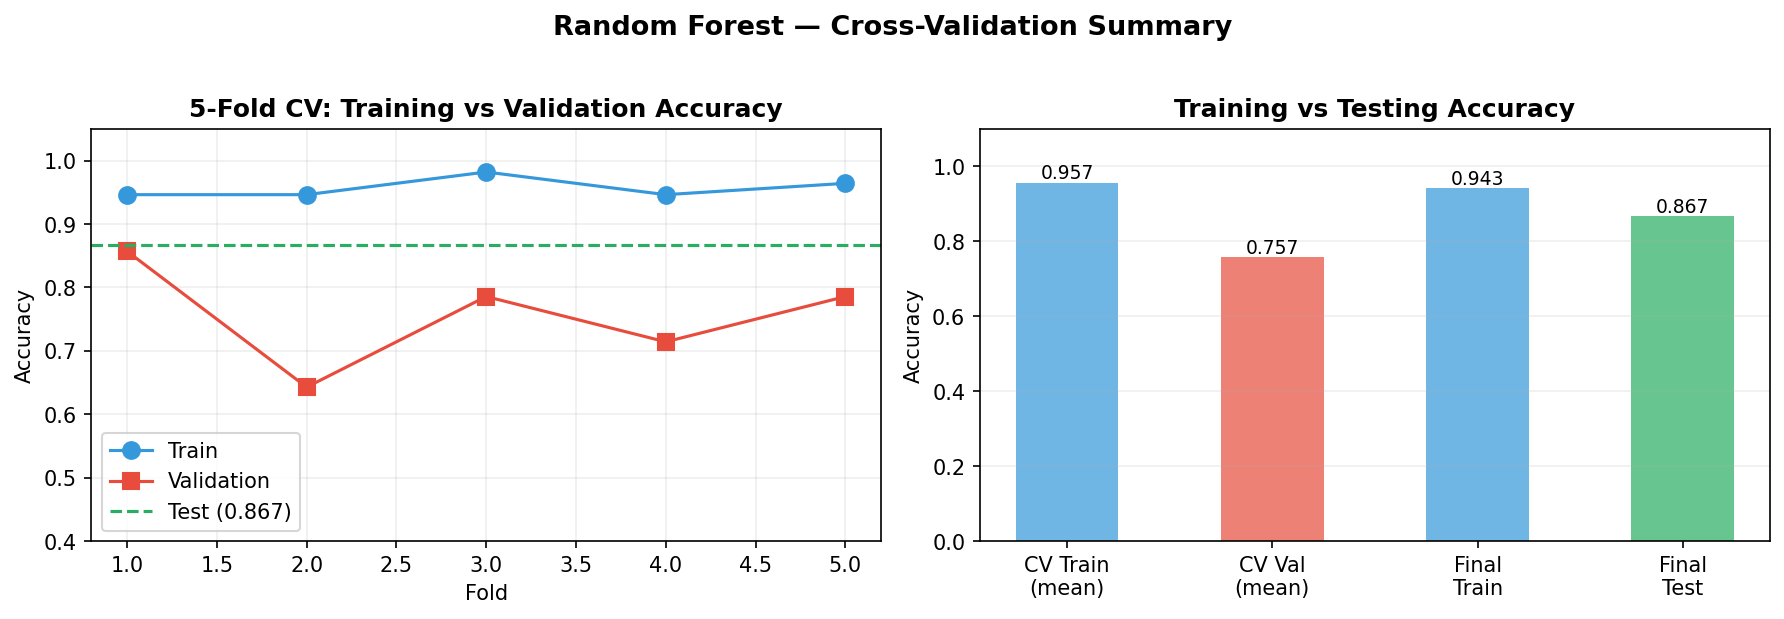

In [46]:
# ============================================================
# 2.1  CV training vs validation accuracy plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x = fold_df['fold']
ax.plot(x, fold_df['train_acc'], 'o-', color='#3498DB', label='Train', ms=8)
ax.plot(x, fold_df['val_acc'], 's-', color='#E74C3C', label='Validation', ms=8)
ax.axhline(test_acc, color='#27AE60', ls='--', lw=1.5, label=f'Test ({test_acc:.3f})')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_title('5-Fold CV: Training vs Validation Accuracy')
ax.set_ylim(0.4, 1.05); ax.legend(); ax.grid(alpha=0.2)

ax = axes[1]
bars = ax.bar(['CV Train\n(mean)', 'CV Val\n(mean)', 'Final\nTrain', 'Final\nTest'],
              [fold_df['train_acc'].mean(), fold_df['val_acc'].mean(), train_full_acc, test_acc],
              color=['#3498DB', '#E74C3C', '#3498DB', '#27AE60'], alpha=0.7, width=0.5)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy'); ax.grid(axis='y', alpha=0.2)

plt.suptitle('Random Forest — Cross-Validation Summary', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('paper_cv_accuracy.png', dpi=200, bbox_inches='tight'); plt.show()

---
## 3 — Temporal Scatter: Prediction vs Years from Diagnosis

In [47]:
# ============================================================
# 3.  Temporal scatter plot — per-recording prediction vs time
# ============================================================

# We need per-recording predictions with years_from_diagnosis
# Use the best RF model on ALL ParkCeleb recordings

# Pick the best available model
#model_name = next((n for n in ['RF (multimodal)', 'RF (best gen.)', 'RF (mRMR, CV)']
                   #if n in loaded_models), None)
model_name = 'RF (mRMR, CV)'
#model_name = 'RF (multimodal)'
#model_name = 'RF (best gen.)'

if model_name and temporal is not None:
    saved = loaded_models[model_name]
    model = saved['model']
    model_scaler = saved['scaler']
    model_feats = saved['features']
    
    print(f'Using model: {model_name} ({len(model_feats)} features)')
    
    # Prepare per-recording features
    # If model uses subject-level aggregated features, we still predict per-recording
    # using the recording's own feature values
    for col in model_feats:
        if col not in pc_rec.columns:
            pc_rec[col] = 0.0
    
    X_all = model_scaler.transform(pc_rec[model_feats].fillna(0).values)
    pc_rec['pred'] = model.predict(X_all)
    pc_rec['prob'] = model.predict_proba(X_all)[:, 1]
    pc_rec['correct'] = (pc_rec['pred'] == pc_rec['label']).astype(int)
    
    # Merge with temporal data to get years_from_diagnosis
    # Temporal CSV has columns like: group, subject, video_id, years_from_diagnosis
    # Use whichever column has the video ID
    if 'video_id' in temporal.columns:
        vid_col = 'video_id'
    elif 'video_folder' in temporal.columns:
        vid_col = 'video_folder'
    else:
        vid_col = None
    
    yrs_col = next((c for c in temporal.columns if 'years' in c.lower()), None)
    ba_col = next((c for c in temporal.columns if 'before_after' in c.lower()), None)
    
    if yrs_col:
        temporal[yrs_col] = pd.to_numeric(temporal[yrs_col], errors='coerce')
        
        # Find the before/after column
        ba_col = next((c for c in temporal.columns if 'before_after' in c.lower()), None)
        
        # Build merge table
        merge_cols = ['subject', vid_col, yrs_col]
        if ba_col: merge_cols.append(ba_col)
        merge_temp = temporal[merge_cols].drop_duplicates()
        if vid_col != 'video_id':
            merge_temp = merge_temp.rename(columns={vid_col: 'video_id'})
        
        pc_rec = pc_rec.loc[:, ~pc_rec.columns.duplicated()]
        pc_temporal = pc_rec.merge(merge_temp, on=['subject', 'video_id'], how='left')
        
        # Create signed years: negative for "before", positive for "after", 0 for "same"
        if ba_col:
            ba_lower = pc_temporal[ba_col].astype(str).str.strip().str.lower()
            pc_temporal['signed_years'] = pc_temporal[yrs_col]
            pc_temporal.loc[ba_lower == 'before', 'signed_years'] = -pc_temporal[yrs_col]
            pc_temporal.loc[ba_lower == 'same', 'signed_years'] = 0
        else:
            pc_temporal['signed_years'] = pc_temporal[yrs_col]
        
        has_years = pc_temporal['signed_years'].notna()
        print(f'Recordings with temporal data: {has_years.sum()}/{len(pc_temporal)}')
        if ba_col:
            before_n = (ba_lower == 'before').sum()
            after_n = (ba_lower == 'after').sum()
            same_n = (ba_lower == 'same').sum()
            print(f'  Before diagnosis: {before_n}  |  After: {after_n}  |  Same year: {same_n}')
        
        pc_plot = pc_temporal[has_years].copy()
    else:
        print('No years_from_diagnosis column found in temporal data')
        pc_plot = None
else:
    print('Model or temporal data not available.')
    print('  Set TEMPORAL_CSV to the target_recordings.csv from parkceleb_temporal.py')
    pc_plot = None

Using model: RF (mRMR, CV) (24 features)
Recordings with temporal data: 48301/143941
  Before diagnosis: 16768  |  After: 29334  |  Same year: 2199


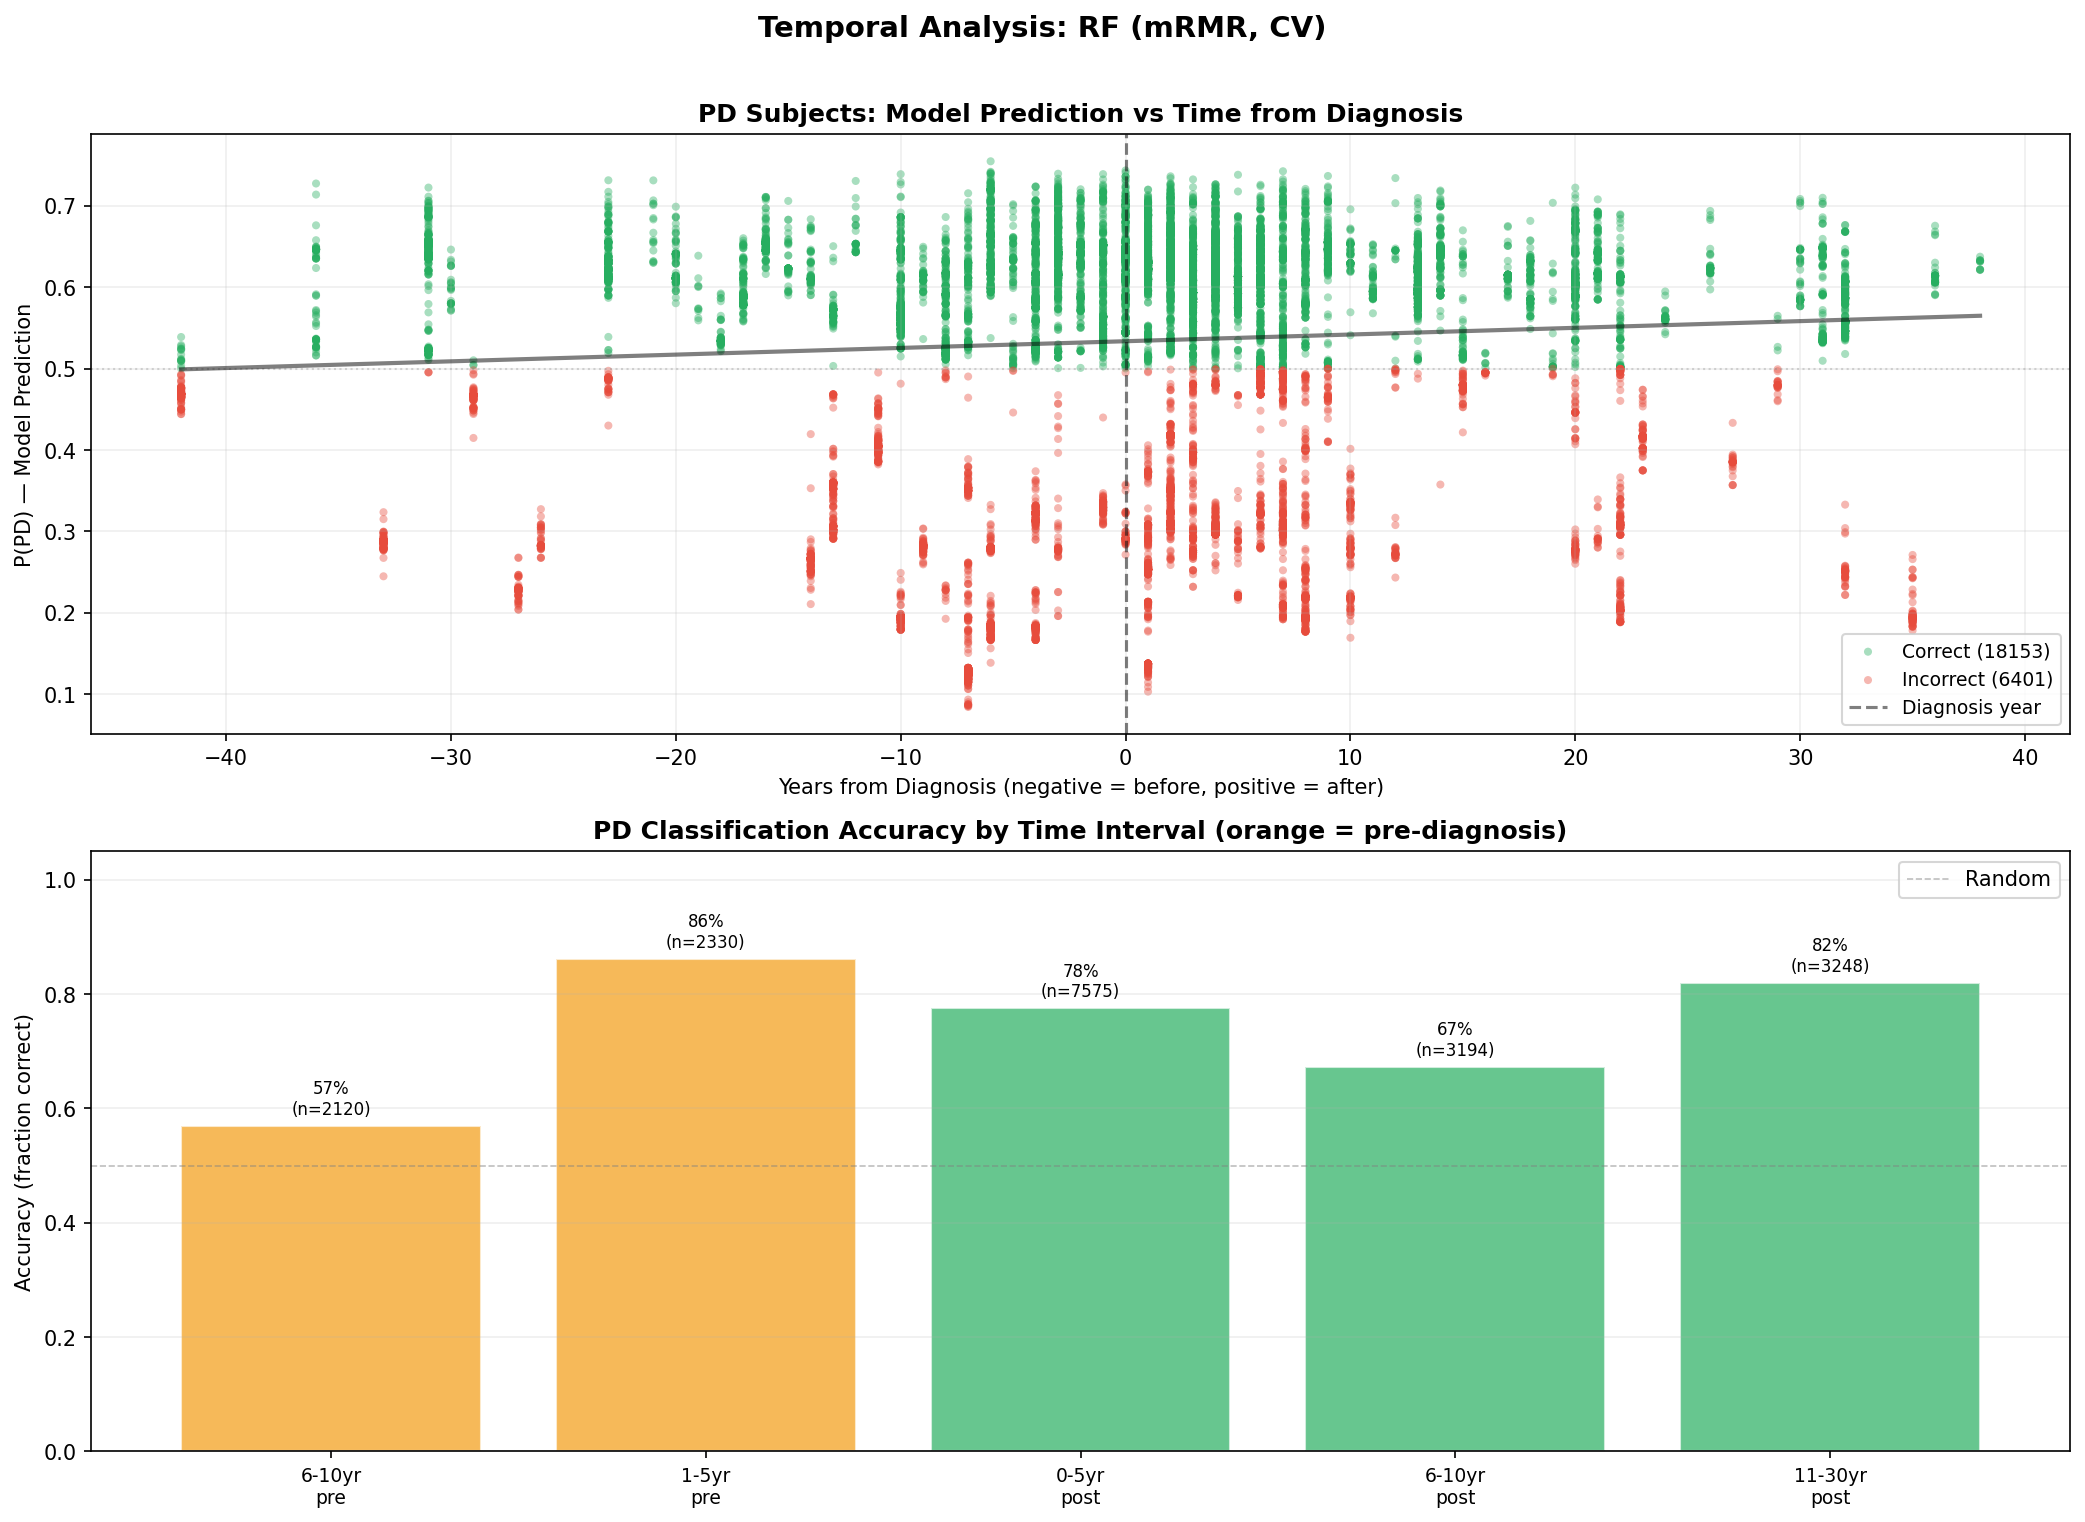

In [48]:
# ============================================================
# 3.1  Temporal scatter: years from diagnosis vs prediction
# ============================================================
if pc_plot is not None and 'signed_years' in pc_plot.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Panel 1: PD subjects only
    ax = axes[0]
    pd_plot = pc_plot[pc_plot['label'] == 1]
    correct = pd_plot[pd_plot['correct'] == 1]
    wrong = pd_plot[pd_plot['correct'] == 0]

    ax.scatter(correct['signed_years'], correct['prob'], s=15, alpha=0.4,
               c='#27AE60', label=f'Correct ({len(correct)})', edgecolors='none')
    ax.scatter(wrong['signed_years'], wrong['prob'], s=15, alpha=0.4,
               c='#E74C3C', label=f'Incorrect ({len(wrong)})', edgecolors='none')

    ax.axvline(0, color='black', ls='--', lw=1.5, alpha=0.5, label='Diagnosis year')
    ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.3)
    ax.set_xlabel('Years from Diagnosis (negative = before, positive = after)')
    ax.set_ylabel('P(PD) — Model Prediction')
    ax.set_title('PD Subjects: Model Prediction vs Time from Diagnosis')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.2)

    # Add trend line
    valid = pd_plot['signed_years'].notna()
    if valid.sum() > 10:
        z = np.polyfit(pd_plot.loc[valid, 'signed_years'].values,
                       pd_plot.loc[valid, 'prob'].values, 1)
        trend_x = np.linspace(pd_plot['signed_years'].min(), pd_plot['signed_years'].max(), 100)
        ax.plot(trend_x, np.polyval(z, trend_x), 'k-', lw=2, alpha=0.5, label='Trend')

    # Panel 2: Accuracy by time bin (now using signed years)
    ax = axes[1]
    #bins = [(-40, -10), (-10, -5), (-5, -1), (-1, 0), (0, 5), (5, 10), (10, 40)]
    #bin_labels = ['10-40yr\npre', '5-10yr\npre', '1-5yr\npre', '0-1yr\npre',
                  #'0-5yr\npost', '5-10yr\npost', '10-40yr\npost']
    bins = [(-10, -6), (-5, -1), (0, 5), (6, 10), (11, 30)]
    bin_labels = ['6-10yr\npre', '1-5yr\npre',
                  '0-5yr\npost', '6-10yr\npost', '11-30yr\npost']
    bin_accs = []
    bin_counts = []

    for lo, hi in bins:
        mask = (pd_plot['signed_years'] >= lo) & (pd_plot['signed_years'] < hi)
        subset = pd_plot[mask]
        if len(subset) > 0:
            bin_accs.append(subset['correct'].mean())
            bin_counts.append(len(subset))
        else:
            bin_accs.append(0)
            bin_counts.append(0)

    bar_colors = ['#F39C12' if lo < 0 else '#27AE60' for lo, hi in bins]
    bars = ax.bar(range(len(bins)), bin_accs, color=bar_colors, alpha=0.7, edgecolor='white')
    ax.set_xticks(range(len(bins)))
    ax.set_xticklabels(bin_labels, fontsize=9)
    ax.set_ylabel('Accuracy (fraction correct)')
    ax.set_title('PD Classification Accuracy by Time Interval (orange = pre-diagnosis)')
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5, label='Random')
    ax.set_ylim(0, 1.05)

    for i, (bar, count) in enumerate(zip(bars, bin_counts)):
        if count > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{bar.get_height():.0%}\n(n={count})', ha='center', fontsize=8)
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    plt.suptitle(f'Temporal Analysis: {model_name}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('paper_temporal_scatter.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('Skipping temporal plot (data not available)')

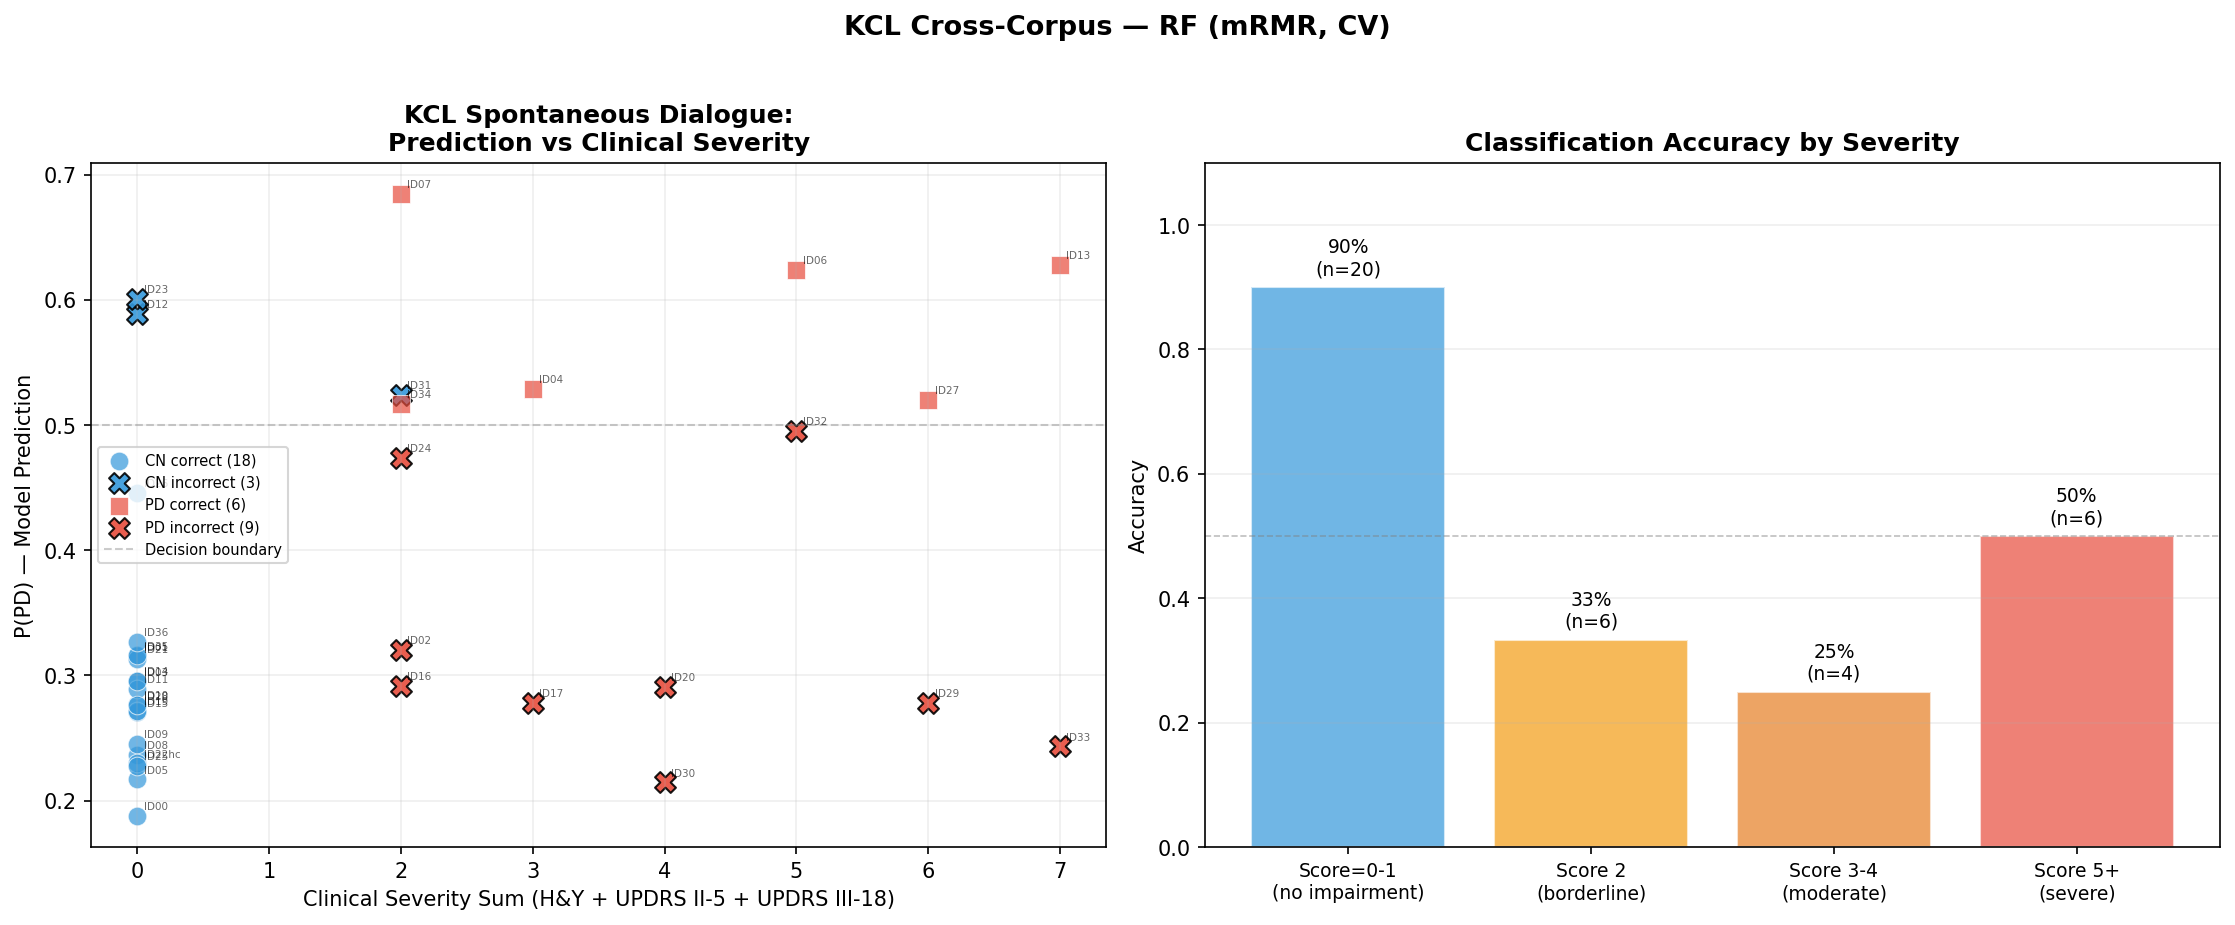


Subject     True  Pred  OK   P(PD)  H&Y  UII  UIII  Sum
──────────────────────────────────────────────────
ID00          CN    CN   ✓   0.188    0    0     0    0
ID01          CN    CN   ✓   0.315    0    0     0    0
ID03          CN    CN   ✓   0.295    0    0     0    0
ID05          CN    CN   ✓   0.217    0    0     0    0
ID11          CN    CN   ✓   0.289    0    0     0    0
ID10          CN    CN   ✓   0.277    0    0     0    0
ID09          CN    CN   ✓   0.246    0    0     0    0
ID08          CN    CN   ✓   0.237    0    0     0    0
ID12          CN    PD   ✗   0.589    0    0     0    0
ID14          CN    CN   ✓   0.296    0    0     0    0
ID15          CN    CN   ✓   0.271    0    0     0    0
ID26          CN    CN   ✓   0.446    0    0     0    0
ID21          CN    CN   ✓   0.313    0    0     0    0
ID22hc        CN    CN   ✓   0.230    0    0     0    0
ID23          CN    PD   ✗   0.601    0    0     0    0
ID19          CN    CN   ✓   0.272    0    0     0  

In [49]:
# ============================================================
# 6.  KCL Cross-Corpus: Prediction vs Clinical Severity Score
# ============================================================
# X-axis = H&Y + UPDRS II-5 + UPDRS III-18 (from filename)
# Y-axis = model prediction probability
# Run on SpontaneousDialogue only

# Load KCL dialogue data
if os.path.isfile(CYMO_KCL_SD) and os.path.isfile(META_KCL_SD):
    kcl_sd_cymo = pd.read_csv(CYMO_KCL_SD)
    kcl_sd_meta = pd.read_csv(META_KCL_SD)
    
    tc = 'TID' if 'TID' in kcl_sd_cymo.columns else kcl_sd_cymo.columns[0]
    mc = 'TID' if 'TID' in kcl_sd_meta.columns else kcl_sd_meta.columns[0]
    sc = next((c for c in kcl_sd_meta.columns if c in ('subject', 'subject_id')), None)
    
    kcl_sd = kcl_sd_cymo.merge(kcl_sd_meta[[mc, 'group', sc, 'source_file',
                                              'hy_score', 'updrs_ii_5', 'updrs_iii_18']].drop_duplicates(),
                                left_on=tc, right_on=mc, how='inner')
    if sc != 'subject':
        kcl_sd = kcl_sd.rename(columns={sc: 'subject'})
    kcl_sd['group'] = kcl_sd['group'].replace({'HC': 'CN'})
    kcl_sd['label'] = (kcl_sd['group'] == 'PD').astype(int)
    
    # Parse severity scores from filename or metadata columns
    kcl_sd['hy'] = pd.to_numeric(kcl_sd['hy_score'], errors='coerce').fillna(0)
    kcl_sd['u2'] = pd.to_numeric(kcl_sd['updrs_ii_5'], errors='coerce').fillna(0)
    kcl_sd['u3'] = pd.to_numeric(kcl_sd['updrs_iii_18'], errors='coerce').fillna(0)
    kcl_sd['severity_sum'] = kcl_sd['hy'] + kcl_sd['u2'] + kcl_sd['u3']
    
    # Aggregate to subject level
    kcl_sd_subj = kcl_sd.groupby('subject').agg(
        {**{f: 'mean' for f in model_feats if f in kcl_sd.columns},
         'label': 'first', 'group': 'first',
         'severity_sum': 'first', 'hy': 'first', 'u2': 'first', 'u3': 'first',
         'source_file': 'first'}
    ).reset_index()
    
    for col in model_feats:
        if col not in kcl_sd_subj.columns:
            kcl_sd_subj[col] = 0.0
    
    # Predict
    kcl_sd_subj = kcl_sd_subj.loc[:, ~kcl_sd_subj.columns.duplicated()]
    X_kcl = model_scaler.transform(kcl_sd_subj[model_feats].fillna(0).values)
    kcl_sd_subj['pred'] = model.predict(X_kcl)
    kcl_sd_subj['prob'] = model.predict_proba(X_kcl)[:, 1]
    kcl_sd_subj['correct'] = (kcl_sd_subj['pred'] == kcl_sd_subj['label']).astype(int)
    
    # ---- Plot ----
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Panel 1: Scatter — severity sum vs P(PD)
    ax = axes[0]
    for grp, color, marker in [('CN', '#3498DB', 'o'), ('PD', '#E74C3C', 's')]:
        sub = kcl_sd_subj[kcl_sd_subj['group'] == grp]
        correct_sub = sub[sub['correct'] == 1]
        wrong_sub = sub[sub['correct'] == 0]
        
        ax.scatter(correct_sub['severity_sum'], correct_sub['prob'],
                   c=color, marker=marker, s=80, alpha=0.7, edgecolors='white', linewidth=0.5,
                   label=f'{grp} correct ({len(correct_sub)})')
        ax.scatter(wrong_sub['severity_sum'], wrong_sub['prob'],
                   c=color, marker='X', s=100, alpha=0.9, edgecolors='black', linewidth=1,
                   label=f'{grp} incorrect ({len(wrong_sub)})')
        
        # Label each point with subject ID
        for _, row in sub.iterrows():
            ax.annotate(row['subject'], (row['severity_sum'], row['prob']),
                       fontsize=5, alpha=0.6, xytext=(3, 3), textcoords='offset points')
    
    ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.4, label='Decision boundary')
    ax.set_xlabel('Clinical Severity Sum (H&Y + UPDRS II-5 + UPDRS III-18)')
    ax.set_ylabel('P(PD) — Model Prediction')
    ax.set_title('KCL Spontaneous Dialogue:\nPrediction vs Clinical Severity')
    ax.legend(fontsize=7, loc='center left')
    ax.grid(alpha=0.2)
    
    # Panel 2: Bar — accuracy by severity bin
    ax = axes[1]
    sev_bins = [(0, 1, 'Score=0-1\n(no impairment)'),
                (2, 2, 'Score 2\n(borderline)'),
                (3, 4, 'Score 3-4\n(moderate)'),
                (5, 12, 'Score 5+\n(severe)')]
    bin_accs, bin_counts, bin_labels_plot = [], [], []
    
    for lo, hi, label in sev_bins:
        mask = (kcl_sd_subj['severity_sum'] >= lo) & (kcl_sd_subj['severity_sum'] <= hi)
        sub = kcl_sd_subj[mask]
        if len(sub) > 0:
            bin_accs.append(sub['correct'].mean())
            bin_counts.append(len(sub))
        else:
            bin_accs.append(0)
            bin_counts.append(0)
        bin_labels_plot.append(label)
    
    bar_colors = ['#3498DB', '#F39C12', '#E67E22', '#E74C3C']
    bars = ax.bar(range(len(sev_bins)), bin_accs, color=bar_colors, alpha=0.7, edgecolor='white')
    ax.set_xticks(range(len(sev_bins)))
    ax.set_xticklabels(bin_labels_plot, fontsize=9)
    ax.set_ylabel('Accuracy')
    ax.set_title('Classification Accuracy by Severity')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
    
    for i, (bar, count) in enumerate(zip(bars, bin_counts)):
        if count > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{bar.get_height():.0%}\n(n={count})', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.2)
    
    plt.suptitle(f'KCL Cross-Corpus — {model_name}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('paper_kcl_severity.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    # Print detail table
    print(f'\n{"Subject":<10s} {"True":>5s} {"Pred":>5s} {"OK":>3s} {"P(PD)":>7s} {"H&Y":>4s} {"UII":>4s} {"UIII":>5s} {"Sum":>4s}')
    print('─' * 50)
    for _, r in kcl_sd_subj.sort_values('severity_sum').iterrows():
        true = 'PD' if r['label'] == 1 else 'CN'
        pred = 'PD' if r['pred'] == 1 else 'CN'
        ok = '✓' if r['correct'] else '✗'
        print(f'{r["subject"]:<10s} {true:>5s} {pred:>5s} {ok:>3s} {r["prob"]:>7.3f} '
              f'{r["hy"]:>4.0f} {r["u2"]:>4.0f} {r["u3"]:>5.0f} {r["severity_sum"]:>4.0f}')
    
    total_acc = kcl_sd_subj['correct'].mean()
    print(f'\nOverall accuracy: {total_acc:.3f} ({kcl_sd_subj["correct"].sum()}/{len(kcl_sd_subj)})')
else:
    print('KCL Dialogue CYMO files not found — skipping severity plot')

---
## 4 — All-Models Comparison Table & Figures

In [50]:
# ============================================================
# 4.  Evaluate every loaded model on ParkCeleb test + KCL
# ============================================================

# KCL data (load once)
kcl_dfs = []
for cp, mp in [(CYMO_KCL_RT, META_KCL_RT), (CYMO_KCL_SD, META_KCL_SD)]:
    if not os.path.isfile(cp): continue
    c = pd.read_csv(cp); m = pd.read_csv(mp)
    tc = 'TID' if 'TID' in c.columns else c.columns[0]
    mc = 'TID' if 'TID' in m.columns else m.columns[0]
    sc = next((x for x in m.columns if x in ('subject','subject_id')), None)
    merged = c.merge(m[[mc,'group',sc]].drop_duplicates(), left_on=tc, right_on=mc, how='inner')
    if sc != 'subject': merged = merged.rename(columns={sc: 'subject'})
    merged['group'] = merged['group'].replace({'HC': 'CN'})
    merged['label'] = (merged['group'] == 'PD').astype(int)
    kcl_dfs.append(merged)

#kcl_all = pd.concat(kcl_dfs, ignore_index=True) if kcl_dfs else None
kcl_all = pd.concat(kcl_dfs, ignore_index=True) if kcl_dfs else None
kcl_rt = kcl_dfs[0] if len(kcl_dfs) > 0 else None   # ReadText
kcl_sd = kcl_dfs[1] if len(kcl_dfs) > 1 else None   # Dialogue

# KCL acoustic
kcl_ac = None
if os.path.isfile(KCL_ACOUSTIC):
    kcl_ac = pd.read_csv(KCL_ACOUSTIC)
    kcl_ac['group'] = kcl_ac['group'].replace({'HC': 'CN'})
    if 'subject' not in kcl_ac.columns and 'filename' in kcl_ac.columns:
        kcl_ac['subject'] = kcl_ac['filename'].str.split('_').str[0]

# Evaluate each model
comparison = []

for name, saved in loaded_models.items():
    model = saved['model']
    model_sc = saved['scaler']
    model_feats = saved['features']
    
    # ParkCeleb test (70/30 split, seed=42)
    for col in model_feats:
        if col not in pc_subj.columns: pc_subj[col] = 0.0
    
    np.random.seed(42)
    cn_s = pc_subj[pc_subj['label']==0].sample(frac=1, random_state=42)
    pd_s = pc_subj[pc_subj['label']==1].sample(frac=1, random_state=42)
    cs, ps = int(len(cn_s)*0.7), int(len(pd_s)*0.7)
    test = pd.concat([cn_s.iloc[cs:], pd_s.iloc[ps:]])
    
    try:
        X_te = model_sc.transform(test[model_feats].fillna(0).values)
        y_te = test['label'].values
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        
        pc_result = {
            'pc_acc': accuracy_score(y_te, y_pred),
            'pc_f1': f1_score(y_te, y_pred, zero_division=0),
            'pc_auc': roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5,
            'pc_sens': recall_score(y_te, y_pred, zero_division=0),
            'pc_spec': recall_score(y_te, y_pred, pos_label=0, zero_division=0),
        }
    except Exception as e:
        pc_result = {'pc_acc': 0, 'pc_f1': 0, 'pc_auc': 0.5, 'pc_sens': 0, 'pc_spec': 0}
    
    # KCL cross-corpus
    kcl_result = {'kcl_rt_acc': '-', 'kcl_rt_auc': '-', 'kcl_sd_acc': '-', 'kcl_sd_auc': '-'}
    
    for kcl_data, prefix in [(kcl_rt, 'kcl_rt'), (kcl_sd, 'kcl_sd')]:
        if kcl_data is None: continue
        try:
            kcl_subj = kcl_data.groupby('subject').agg(
                {**{f: 'mean' for f in model_feats if f in kcl_data.columns}, 'label': 'first'}
            ).reset_index()
            for col in model_feats:
                if col not in kcl_subj.columns: kcl_subj[col] = 0.0
            X_kcl = model_sc.transform(kcl_subj[model_feats].fillna(0).values)
            y_kcl = kcl_subj['label'].values
            kcl_result[f'{prefix}_acc'] = accuracy_score(y_kcl, model.predict(X_kcl))
            kcl_result[f'{prefix}_auc'] = roc_auc_score(y_kcl, model.predict_proba(X_kcl)[:,1]) if len(np.unique(y_kcl))>1 else 0.5
        except Exception:
            pass
    
    comparison.append({'model': name, 'n_features': len(model_feats), **pc_result, **kcl_result})

comp_df = pd.DataFrame(comparison)

print('ALL MODELS — COMPARISON TABLE')
print('=' * 115)
print(f'{"Model":<25s} {"#Feat":>6s} {"PC Acc":>7s} {"KCL SD Acc":>10s}')
print('─' * 115)
for _, r in comp_df.iterrows():
    def fmt(v): return f'{v:.3f}' if isinstance(v, float) else str(v)
    print(f'{r["model"]:<25s} {r["n_features"]:>6d} {r["pc_acc"]:>7.3f} '
          f'{fmt(r["kcl_sd_acc"]):>10s}')
    #print(f'{r["model"]:<25s} {r["n_features"]:>6d} {r["pc_acc"]:>7.3f} {r["pc_auc"]:>7.3f} '
          #f'{r["pc_sens"]:>8.3f} {r["pc_spec"]:>8.3f} {fmt(r["kcl_rt_acc"]):>10s} {fmt(r["kcl_rt_auc"]):>10s} '
          #f'{fmt(r["kcl_sd_acc"]):>10s} {fmt(r["kcl_sd_auc"]):>10s}')

ALL MODELS — COMPARISON TABLE
Model                      #Feat  PC Acc KCL SD Acc
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
RF (mRMR, CV)                 24   0.767      0.667
RF (multimodal)               27   0.933      0.556
SVM                           24   0.900      0.556
Gradient Boosting             24   0.867      0.500


In [51]:
# ============================================================
# CLEAN KCL CROSS-CORPUS TEST (Spontaneous Dialogue only)
# Each model uses its OWN saved scaler — no shared state
# ============================================================
import pandas as pd, numpy as np, joblib, os
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score
from sklearn.preprocessing import StandardScaler

# Paths
#CYMO_KCL_SD = '../KCL/ann.cymo_kcl_dialogue_full.csv'
#META_KCL_SD = './cymo_kcl_dialogue_full_metadata.csv'

CYMO_KCL_SD = '../KCL/ann.cymo_kcl_dialogue_full.csv'
META_KCL_SD = './cymo_kcl_dialogue_full_metadata.csv'

MODELS = {
    #'LR (Base)':        './logreg_mrmr.joblib',
    #'LR (Base)':        './logreg_old.joblib',
    #'RF (Base)':        './rf_mrmr.joblib',
    'RF (mRMR, CV)':     './rf_mrmr_cv.joblib',
    'RF (multimodal)':   './rf_multimodal.joblib',
    #'RF (best gen.)':    './rf_best_generalising.joblib',
    'SVM':               './svm_best.joblib',
    'Gradient Boosting': './gb_best.joblib',
}

# Load KCL dialogue CYMO data ONCE
kcl_cymo = pd.read_csv(CYMO_KCL_SD)
kcl_meta = pd.read_csv(META_KCL_SD)

tc = 'TID' if 'TID' in kcl_cymo.columns else kcl_cymo.columns[0]
mc = 'TID' if 'TID' in kcl_meta.columns else kcl_meta.columns[0]
sc = next((c for c in kcl_meta.columns if c in ('subject', 'subject_id')), None)

kcl = kcl_cymo.merge(kcl_meta[[mc, 'group', sc]].drop_duplicates(),
                      left_on=tc, right_on=mc, how='inner')
if sc != 'subject':
    kcl = kcl.rename(columns={sc: 'subject'})
kcl['group'] = kcl['group'].replace({'HC': 'CN'})
kcl['label'] = (kcl['group'] == 'PD').astype(int)
kcl = kcl.loc[:, ~kcl.columns.duplicated()]

print(f'KCL Dialogue: {len(kcl)} recordings, {kcl["subject"].nunique()} subjects')
print(f'  CN: {kcl[kcl["label"]==0]["subject"].nunique()}  PD: {kcl[kcl["label"]==1]["subject"].nunique()}\n')

# Also load ParkCeleb for comparison (subject-level)
CYMO_PC = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_PC = './cymo_parkceleb_per_recording_metadata.csv'

pc_cymo = pd.read_csv(CYMO_PC)
pc_meta = pd.read_csv(META_PC)
ptc = 'TID' if 'TID' in pc_cymo.columns else pc_cymo.columns[0]
pmc = 'TID' if 'TID' in pc_meta.columns else pc_meta.columns[0]
pc = pc_cymo.merge(pc_meta[[pmc, 'group', 'subject']].drop_duplicates(),
                    left_on=ptc, right_on=pmc, how='inner')
pc['label'] = (pc['group'] == 'PD').astype(int)
pc = pc.loc[:, ~pc.columns.duplicated()]

# Evaluate each model using Utterance-Level Prediction & Subject-Level Voting
print(f'{"Model":<25s} {"PC Test Acc":>11s} {"KCL SD Acc":>11s} {"KCL SD AUC":>11s}')
print('─' * 62)

for name, path in MODELS.items():
    if not os.path.isfile(path):
        print(f'{name:<25s} — file not found')
        continue

    saved = joblib.load(path)
    model = saved['model']
    model_scaler = saved['scaler']
    feats = saved['features']

    # ---- ParkCeleb test (same 70/30 split) ----
    pc_df = pc.copy()
    for col in feats:
        if col not in pc_df.columns: pc_df[col] = 0.0
        pc_df[col] = pd.to_numeric(pc_df[col], errors='coerce')

    pc_subj = pc_df.groupby('subject').agg(
        {**{f: 'mean' for f in feats}, 'label': 'first'}
    ).reset_index().fillna(0)

    np.random.seed(42)
    cn_s = pc_subj[pc_subj['label']==0].sample(frac=1, random_state=42)
    pd_s = pc_subj[pc_subj['label']==1].sample(frac=1, random_state=42)
    cs, ps = int(len(cn_s)*0.7), int(len(pd_s)*0.7)
    pc_test = pd.concat([cn_s.iloc[cs:], pd_s.iloc[ps:]])

    try:
        X_pc = model_scaler.transform(pc_test[feats].values)
        pc_acc = accuracy_score(pc_test['label'].values, model.predict(X_pc))
    except Exception as e:
        pc_acc = f'ERR'

    # ---- KCL Dialogue (FIXED: Segment-level prediction -> Subject aggregation) ----
    kcl_df = kcl.copy()
    for col in feats:
        if col not in kcl_df.columns: 
            kcl_df[col] = 0.0
        kcl_df[col] = pd.to_numeric(kcl_df[col], errors='coerce')

    try:
        # 1. Scale and predict on individual records/utterances
        X_kcl = kcl_df[feats].fillna(0).values
        X_kcl_scaled = model_scaler.transform(X_kcl)
        
        kcl_df['pred'] = model.predict(X_kcl_scaled)
        kcl_df['prob'] = model.predict_proba(X_kcl_scaled)[:, 1]
        
        # 2. Perform late fusion / decision voting at the subject level
        kcl_subj = kcl_df.groupby('subject').agg(
            true_label=('label', 'first'),
            mean_prob=('prob', 'mean'),
            vote_pred=('pred', lambda x: int(x.mean() >= 0.5))
        ).reset_index()
        
        # 3. Compute metrics using the voted classifications
        y_kcl_true = kcl_subj['true_label'].values
        y_kcl_pred = kcl_subj['vote_pred'].values
        y_kcl_prob = kcl_subj['mean_prob'].values
        
        kcl_acc = accuracy_score(y_kcl_true, y_kcl_pred)
        kcl_auc = roc_auc_score(y_kcl_true, y_kcl_prob) if len(np.unique(y_kcl_true)) > 1 else 0.5
        
    except Exception as e:
        kcl_acc = f'ERR'
        kcl_auc = f'ERR'

    # Print comparative results
    if isinstance(pc_acc, float) and isinstance(kcl_acc, float):
        print(f'{name:<25s} {pc_acc:>11.3f} {kcl_acc:>11.3f} {kcl_auc:>11.3f}')
    else:
        print(f'{name:<25s} {str(pc_acc):>11s} {str(kcl_acc):>11s} {str(kcl_auc):>11s}')

KCL Dialogue: 573 recordings, 36 subjects
  CN: 21  PD: 15

Model                     PC Test Acc  KCL SD Acc  KCL SD AUC
──────────────────────────────────────────────────────────────
RF (mRMR, CV)                   0.767       0.694       0.683
RF (multimodal)                 0.933       0.667       0.692
SVM                             0.900       0.611       0.454
Gradient Boosting               0.867       0.583       0.584


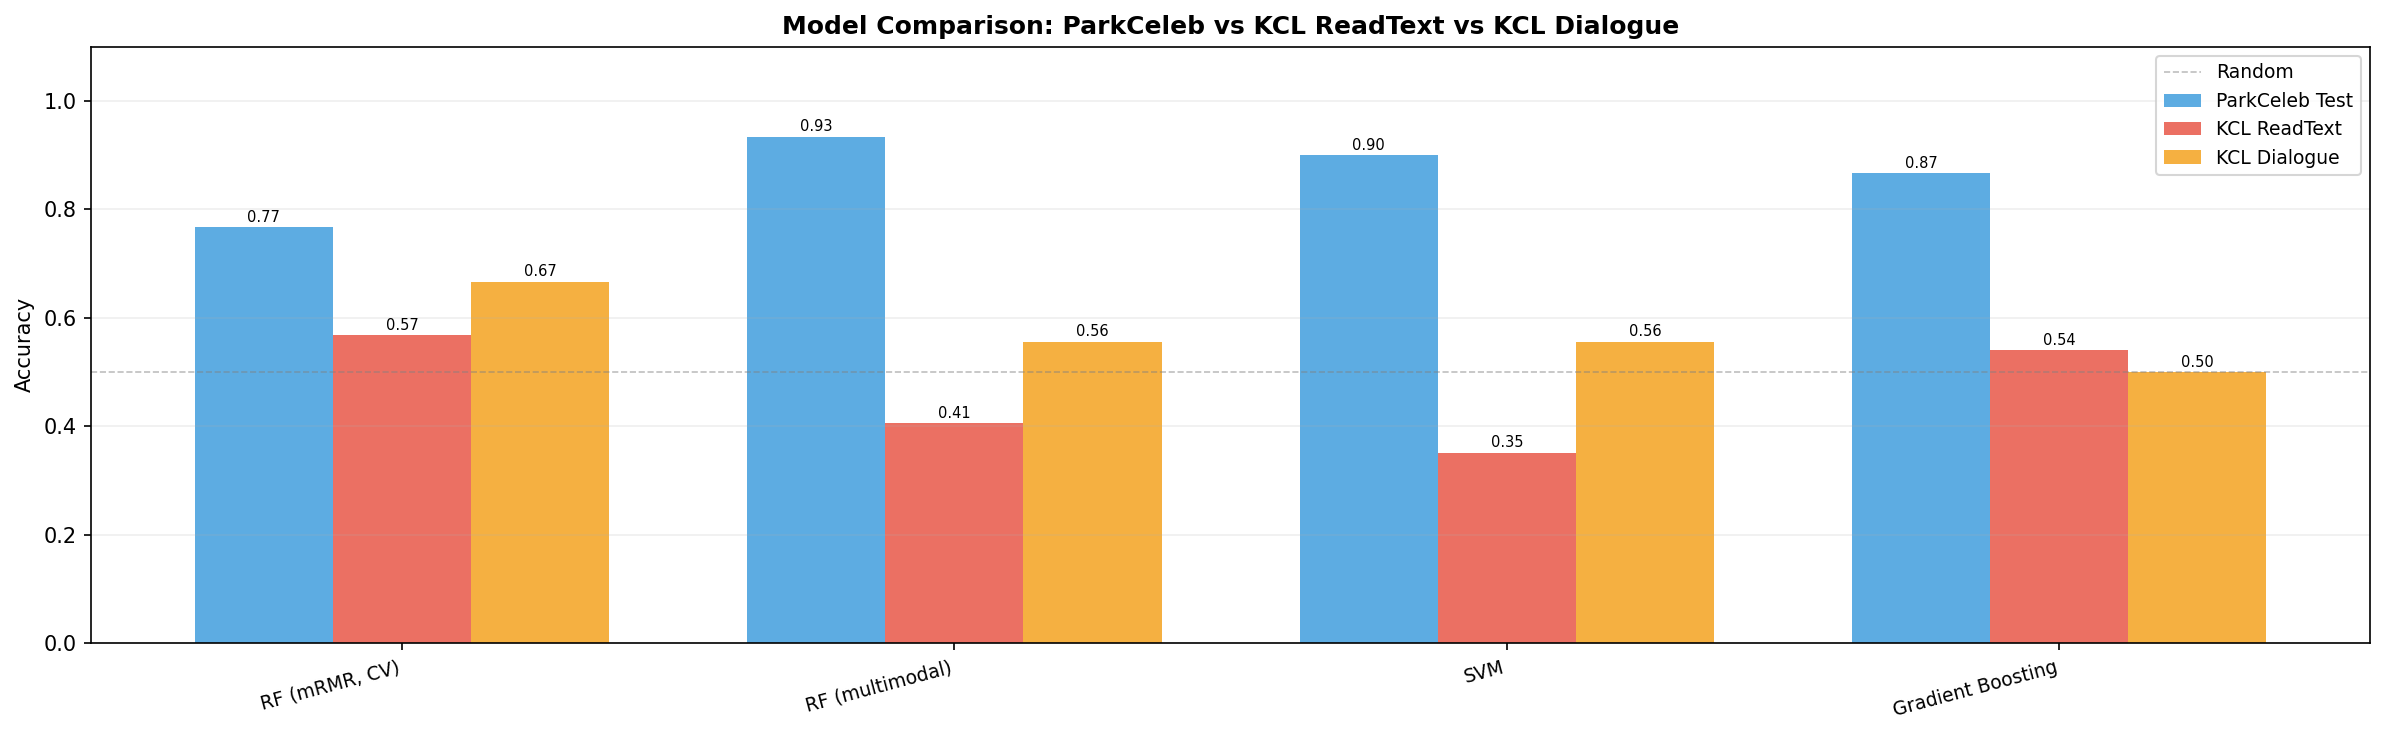

In [52]:
# ============================================================
# 4.1  Paper-ready comparison bar chart
# ============================================================
fig, ax = plt.subplots(figsize=(16, 5))

x = np.arange(len(comp_df))
w = 0.25

bars1 = ax.bar(x - w, comp_df['pc_acc'], w, label='ParkCeleb Test', color='#3498DB', alpha=0.8)

kcl_rt_vals = comp_df['kcl_rt_acc'].apply(lambda v: float(v) if isinstance(v, float) else 0)
kcl_sd_vals = comp_df['kcl_sd_acc'].apply(lambda v: float(v) if isinstance(v, float) else 0)
bars2 = ax.bar(x, kcl_rt_vals, w, label='KCL ReadText', color='#E74C3C', alpha=0.8)
bars3 = ax.bar(x + w, kcl_sd_vals, w, label='KCL Dialogue', color='#F39C12', alpha=0.8)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{bar.get_height():.2f}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(comp_df['model'], fontsize=9, rotation=15, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: ParkCeleb vs KCL ReadText vs KCL Dialogue')
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5, label='Random')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)

plt.tight_layout(); plt.savefig('paper_model_comparison.png', dpi=200, bbox_inches='tight'); plt.show()

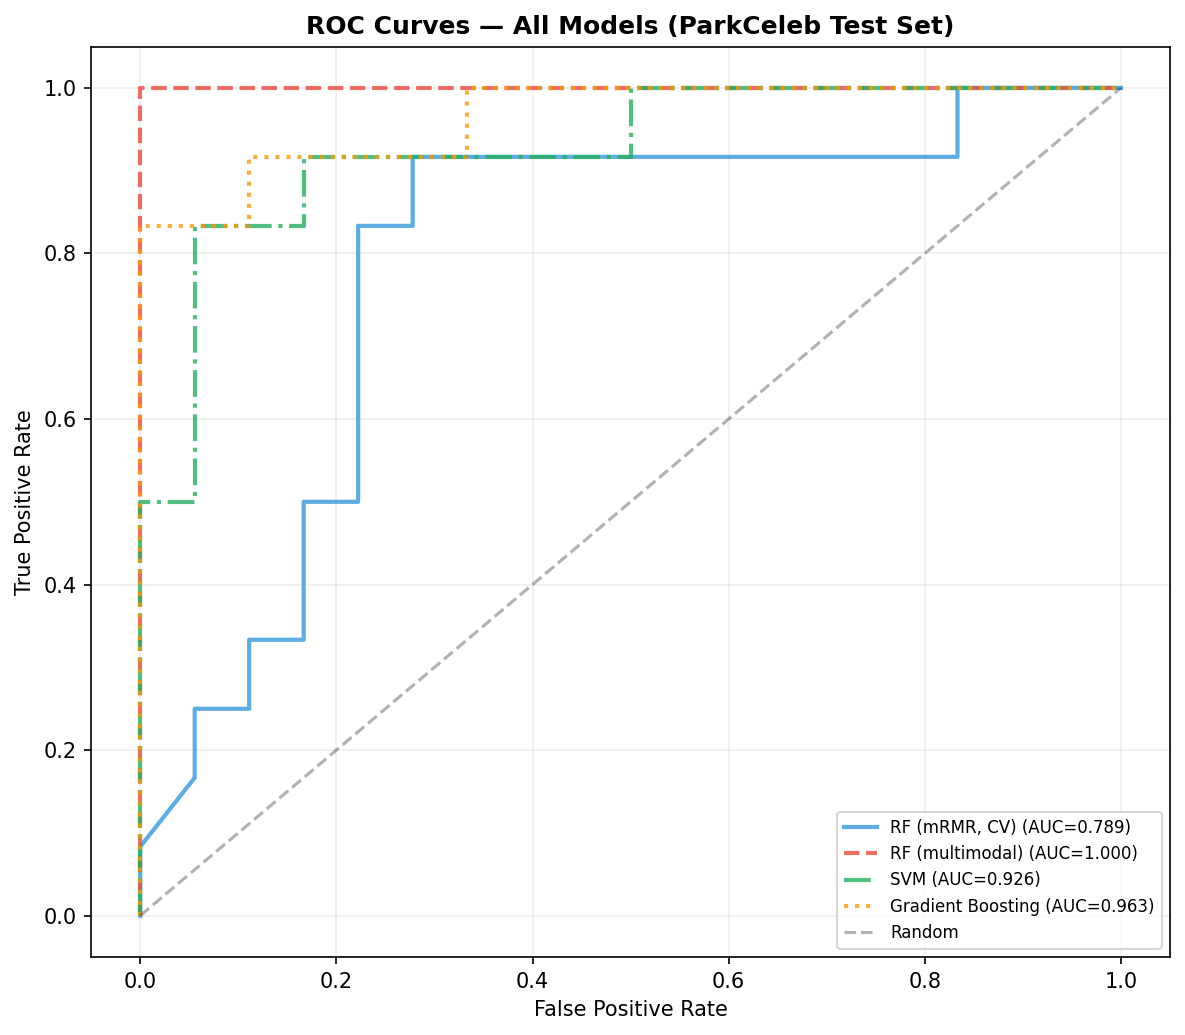

In [53]:
# ============================================================
# 4.2  ROC curves for all models (ParkCeleb test set)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#3498DB', '#E74C3C', '#27AE60', '#F39C12', '#8E44AD', '#2C3E50']
styles = ['-', '--', '-.', ':', '-', '--']

for i, (name, saved) in enumerate(loaded_models.items()):
    try:
        model = saved['model']; model_sc = saved['scaler']; mf = saved['features']
        for col in mf:
            if col not in test.columns: test[col] = 0.0
        X = model_sc.transform(test[mf].fillna(0).values)
        y_prob = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(test['label'].values, y_prob)
        auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i % len(colors)], ls=styles[i % len(styles)],
                lw=2, alpha=0.8, label=f'{name} (AUC={auc_val:.3f})')
    except Exception:
        pass

ax.plot([0,1],[0,1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models (ParkCeleb Test Set)')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout(); plt.savefig('paper_roc_all_models.png', dpi=200, bbox_inches='tight'); plt.show()

In [54]:
# ============================================================
# 5.  Summary table for paper (LaTeX-ready)
# ============================================================
print('| Model | Feat | PC Acc | PC AUC | PC Sens | PC Spec | KCL RT Acc | KCL RT AUC | KCL SD Acc | KCL SD AUC |')
print('|-------|------|--------|--------|---------|---------|------------|------------|------------|------------|')
for _, r in comp_df.iterrows():
    def fmt(v): return f'{v:.3f}' if isinstance(v, float) else '—'
    print(f'| {r["model"]} | {r["n_features"]} | {r["pc_acc"]:.3f} | {r["pc_auc"]:.3f} | '
          f'{r["pc_sens"]:.3f} | {r["pc_spec"]:.3f} | {fmt(r["kcl_rt_acc"])} | {fmt(r["kcl_rt_auc"])} | '
          f'{fmt(r["kcl_sd_acc"])} | {fmt(r["kcl_sd_auc"])} |')

| Model | Feat | PC Acc | PC AUC | PC Sens | PC Spec | KCL RT Acc | KCL RT AUC | KCL SD Acc | KCL SD AUC |
|-------|------|--------|--------|---------|---------|------------|------------|------------|------------|
| RF (mRMR, CV) | 24 | 0.767 | 0.789 | 0.917 | 0.667 | 0.568 | 0.576 | 0.667 | 0.692 |
| RF (multimodal) | 27 | 0.933 | 1.000 | 1.000 | 0.889 | 0.405 | 0.524 | 0.556 | 0.552 |
| SVM | 24 | 0.900 | 0.926 | 0.833 | 0.944 | 0.351 | 0.463 | 0.556 | 0.575 |
| Gradient Boosting | 24 | 0.867 | 0.963 | 0.833 | 0.889 | 0.541 | 0.500 | 0.500 | 0.473 |
